# Optimizacion de Redes Neuronales: Comparacion de Optimizadores

---

## Objetivo

Aplicar y comparar tecnicas de optimizacion en el entrenamiento de una red neuronal, evidenciando como la eleccion del **optimizador** y la **tasa de aprendizaje** afectan:

- La velocidad de convergencia (cuantas epocas tarda en reducir el loss).
- La estabilidad del entrenamiento (suavidad de la curva de loss).
- El desempeno final del modelo (loss y accuracy al terminar).

---

## Optimizadores comparados

Se implementan **cuatro optimizadores** desde cero con NumPy:

| # | Optimizador | Descripcion resumida |
|---|-------------|----------------------|
| 1 | SGD          | Descenso de gradiente estandar |
| 2 | SGD + Momentum | SGD con acumulacion de velocidad |
| 3 | RMSprop      | Ajusta LR por componente usando media movil de gradientes cuadraticos |
| 4 | Adam         | Combina Momentum y RMSprop con correccion de sesgo |

**Elemento fijo en todas las comparaciones:** arquitectura, dataset, semilla aleatoria, numero de epocas y funcion de activacion.  
**Elemento variable:** el optimizador (y en una seccion aparte, la tasa de aprendizaje).

---

## Configuracion base

- **Dataset:** clasificacion binaria sintetico (espiral de dos clases, 200 muestras)
- **Arquitectura:** Entrada(2) -> Oculta1(16, ReLU) -> Oculta2(8, ReLU) -> Salida(1, Sigmoid)
- **Loss:** Binary Cross-Entropy
- **Epocas:** 1000
- **LR base:** 0.01 (igual para todos los optimizadores en la comparacion principal)

---
## 1. Importacion de librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SEMILLA = 42
np.random.seed(SEMILLA)

print("Librerias cargadas correctamente")
print(f"NumPy version: {np.__version__}")

Librerias cargadas correctamente
NumPy version: 2.0.2


---
## 2. Dataset: Clasificacion Binaria en Espiral

Se genera un dataset de espiral de dos clases. Este problema **no es linealmente separable** y requiere que la red aprenda fronteras de decision curvas, lo que lo hace un buen banco de prueba para comparar optimizadores.

Forma de X_train: (200, 2)
Forma de y_train: (200, 1)
Clase 0: 100 muestras  |  Clase 1: 100 muestras


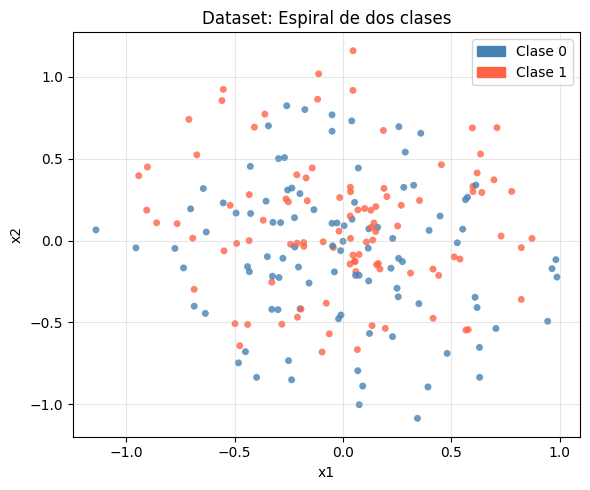

Dataset generado y visualizado


In [ ]:
def generar_espiral(n_por_clase=100, ruido=0.15, semilla=42):
    """Genera dataset de espiral de dos clases."""
    rng = np.random.RandomState(semilla)
    X_list, y_list = [], []
    for clase in range(2):
        t = np.linspace(0, 4 * np.pi, n_por_clase)
        r = t / (4 * np.pi)
        offset = np.pi * clase
        x1 = r * np.cos(t + offset) + rng.randn(n_por_clase) * ruido
        x2 = r * np.sin(t + offset) + rng.randn(n_por_clase) * ruido
        X_list.append(np.column_stack([x1, x2]))
        y_list.append(np.full(n_por_clase, clase))
    X = np.vstack(X_list)
    y = np.concatenate(y_list).reshape(-1, 1).astype(float)
    # Mezclar
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

X_train, y_train = generar_espiral(n_por_clase=100, ruido=0.15, semilla=SEMILLA)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Clase 0: {int((y_train==0).sum())} muestras  |  Clase 1: {int((y_train==1).sum())} muestras")

# Visualizacion del dataset
fig, ax = plt.subplots(figsize=(6, 5))
colores = ['steelblue' if c == 0 else 'tomato' for c in y_train.flatten()]
ax.scatter(X_train[:, 0], X_train[:, 1], c=colores, s=25, alpha=0.8, edgecolors='none')
ax.set_title('Dataset: Espiral de dos clases')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Clase 0'),
                   Patch(color='tomato',    label='Clase 1')])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dataset_espiral.png', dpi=110, bbox_inches='tight')
plt.show()
print("Dataset generado y visualizado")

---
## 3. Funciones Auxiliares

Se definen la funcion de activacion ReLU, Sigmoid y la funcion de loss Binary Cross-Entropy.

In [ ]:
def relu(z):
    return np.maximum(0.0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def bce_loss(y_true, y_pred):
    """Binary Cross-Entropy Loss."""
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred))

def accuracy(y_true, y_pred_prob, umbral=0.5):
    preds = (y_pred_prob >= umbral).astype(int)
    return np.mean(preds == y_true.astype(int))

print("Funciones auxiliares definidas")

Funciones auxiliares definidas


---
## 4. Implementacion de la Red Neuronal

Se define la arquitectura base: dos capas ocultas con ReLU y una capa de salida con Sigmoid.

```
Entrada (2)  ->  Oculta1 (16, ReLU)  ->  Oculta2 (8, ReLU)  ->  Salida (1, Sigmoid)
```

La clase `Red` implementa `forward()` y `backward()`. Los optimizadores se definen por separado y reciben el diccionario de gradientes para actualizar los parametros.

In [ ]:
class Red:
    """
    Red neuronal: Entrada(2) -> Oculta1(16,ReLU) -> Oculta2(8,ReLU) -> Salida(1,Sigmoid).
    Los pesos se inicializan con He (adecuado para ReLU).
    """

    def __init__(self, semilla=42):
        rng = np.random.RandomState(semilla)
        # He initialization
        self.params = {
            'W1': rng.randn(2,  16) * np.sqrt(2.0 / 2),
            'b1': np.zeros((1, 16)),
            'W2': rng.randn(16,  8) * np.sqrt(2.0 / 16),
            'b2': np.zeros((1,  8)),
            'W3': rng.randn(8,   1) * np.sqrt(2.0 / 8),
            'b3': np.zeros((1,  1)),
        }
        self.cache  = {}
        self.grads  = {}

    def forward(self, X):
        p = self.params
        self.cache['X']  = X
        self.cache['z1'] = X @ p['W1'] + p['b1']
        self.cache['a1'] = relu(self.cache['z1'])
        self.cache['z2'] = self.cache['a1'] @ p['W2'] + p['b2']
        self.cache['a2'] = relu(self.cache['z2'])
        self.cache['z3'] = self.cache['a2'] @ p['W3'] + p['b3']
        self.cache['a3'] = sigmoid(self.cache['z3'])
        return self.cache['a3']

    def backward(self, y):
        n  = y.shape[0]
        c  = self.cache
        p  = self.params

        # Capa 3 (salida)
        dz3 = c['a3'] - y
        self.grads['W3'] = (c['a2'].T @ dz3) / n
        self.grads['b3'] = np.mean(dz3, axis=0, keepdims=True)

        # Capa 2
        da2  = dz3 @ p['W3'].T
        dz2  = da2 * relu_deriv(c['z2'])
        self.grads['W2'] = (c['a1'].T @ dz2) / n
        self.grads['b2'] = np.mean(dz2, axis=0, keepdims=True)

        # Capa 1
        da1  = dz2 @ p['W2'].T
        dz1  = da1 * relu_deriv(c['z1'])
        self.grads['W1'] = (c['X'].T @ dz1) / n
        self.grads['b1'] = np.mean(dz1, axis=0, keepdims=True)

        return self.grads


print("Clase Red definida")
print("Arquitectura: Entrada(2) -> Oculta1(16,ReLU) -> Oculta2(8,ReLU) -> Salida(1,Sigmoid)")

Clase Red definida
Arquitectura: Entrada(2) -> Oculta1(16,ReLU) -> Oculta2(8,ReLU) -> Salida(1,Sigmoid)


---
## 5. Implementacion de Optimizadores

In [ ]:
class SGD:
    """Descenso de gradiente estandar."""

    def __init__(self, lr=0.01):
        self.lr   = lr
        self.nombre = f'SGD (lr={lr})'

    def actualizar(self, params, grads):
        for key in params:
            params[key] -= self.lr * grads[key]
        return params


class SGDMomentum:
    """SGD con Momentum."""

    def __init__(self, lr=0.01, beta=0.9):
        self.lr     = lr
        self.beta   = beta
        self.v      = None
        self.nombre = f'SGD+Momentum (lr={lr}, beta={beta})'

    def actualizar(self, params, grads):
        if self.v is None:
            self.v = {k: np.zeros_like(v) for k, v in params.items()}
        for key in params:
            self.v[key] = self.beta * self.v[key] + (1.0 - self.beta) * grads[key]
            params[key] -= self.lr * self.v[key]
        return params


class RMSprop:
    """RMSprop: ajusta la tasa de aprendizaje por componente."""

    def __init__(self, lr=0.01, rho=0.9, eps=1e-8):
        self.lr     = lr
        self.rho    = rho
        self.eps    = eps
        self.s      = None
        self.nombre = f'RMSprop (lr={lr}, rho={rho})'

    def actualizar(self, params, grads):
        if self.s is None:
            self.s = {k: np.zeros_like(v) for k, v in params.items()}
        for key in params:
            self.s[key] = self.rho * self.s[key] + (1.0 - self.rho) * grads[key] ** 2
            params[key] -= self.lr / (np.sqrt(self.s[key]) + self.eps) * grads[key]
        return params


class Adam:
    """Adam: combina Momentum y RMSprop con correccion de sesgo."""

    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr     = lr
        self.beta1  = beta1
        self.beta2  = beta2
        self.eps    = eps
        self.m      = None
        self.v      = None
        self.t      = 0
        self.nombre = f'Adam (lr={lr})'

    def actualizar(self, params, grads):
        if self.m is None:
            self.m = {k: np.zeros_like(v) for k, v in params.items()}
            self.v = {k: np.zeros_like(v) for k, v in params.items()}
        self.t += 1
        for key in params:
            self.m[key] = self.beta1 * self.m[key] + (1.0 - self.beta1) * grads[key]
            self.v[key] = self.beta2 * self.v[key] + (1.0 - self.beta2) * grads[key] ** 2
            m_hat = self.m[key] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[key] / (1.0 - self.beta2 ** self.t)
            params[key] -= self.lr / (np.sqrt(v_hat) + self.eps) * m_hat
        return params


print("Optimizadores definidos: SGD, SGD+Momentum, RMSprop, Adam")

Optimizadores definidos: SGD, SGD+Momentum, RMSprop, Adam


---
## 6. Funcion de Entrenamiento

Se define una funcion generica `entrenar()` que acepta cualquier optimizador, garantizando que la unica diferencia entre experimentos sea el componente de optimizacion.

In [ ]:
def entrenar(X, y, optimizador, epocas=1000, semilla=42, intervalo_log=200):
    """
    Entrena la red neuronal usando el optimizador recibido.

    Parametros
    ----------
    X, y : arrays de entrenamiento
    optimizador : instancia de SGD, SGDMomentum, RMSprop o Adam
    epocas : numero de iteraciones
    semilla : semilla para inicializacion de la red (reproducibilidad)
    intervalo_log : cada cuantas epocas imprimir el estado

    Retorna
    -------
    historial : dict con listas de loss y accuracy por epoca
    red : red entrenada
    """
    red = Red(semilla=semilla)
    hist_loss = []
    hist_acc  = []

    print(f"\n{'='*60}")
    print(f"  Optimizador: {optimizador.nombre}")
    print(f"  Epocas: {epocas}  |  Semilla: {semilla}")
    print(f"{'='*60}")
    print(f"{'Epoca':>7} {'Loss':>12} {'Accuracy':>10}")
    print("-" * 35)

    for ep in range(1, epocas + 1):
        y_pred = red.forward(X)
        loss   = bce_loss(y, y_pred)
        acc    = accuracy(y, y_pred)
        hist_loss.append(loss)
        hist_acc.append(acc)

        grads = red.backward(y)
        red.params = optimizador.actualizar(red.params, grads)

        if ep == 1 or ep % intervalo_log == 0:
            print(f"{ep:>7} {loss:>12.6f} {acc*100:>9.2f}%")

    print(f"{'='*60}")
    return {'loss': np.array(hist_loss), 'acc': np.array(hist_acc)}, red


print("Funcion de entrenamiento definida")

Funcion de entrenamiento definida


---
## 7. Experimento 1: Comparacion de Optimizadores (LR fija = 0.01)

Se entrena la misma red con los cuatro optimizadores usando la misma LR, semilla, dataset y arquitectura.

In [ ]:
EPOCAS = 1000
LR     = 0.01

optimizadores = [
    SGD(lr=LR),
    SGDMomentum(lr=LR, beta=0.9),
    RMSprop(lr=LR, rho=0.9),
    Adam(lr=LR),
]

resultados = {}   # nombre -> historial
redes      = {}   # nombre -> red entrenada

for opt in optimizadores:
    hist, red_entrenada = entrenar(X_train, y_train, opt,
                                   epocas=EPOCAS, semilla=SEMILLA, intervalo_log=200)
    resultados[opt.nombre] = hist
    redes[opt.nombre]      = red_entrenada

print("\nExperimento 1 completado")


  Optimizador: SGD (lr=0.01)
  Epocas: 1000  |  Semilla: 42
  Epoca         Loss   Accuracy
-----------------------------------
      1     0.751263     51.00%
    200     0.689384     51.00%
    400     0.681971     52.50%
    600     0.678981     53.50%
    800     0.676825     54.00%
   1000     0.674904     55.00%

  Optimizador: SGD+Momentum (lr=0.01, beta=0.9)
  Epocas: 1000  |  Semilla: 42
  Epoca         Loss   Accuracy
-----------------------------------
      1     0.751263     51.00%
    200     0.689392     51.00%
    400     0.682050     52.00%
    600     0.679060     53.50%
    800     0.676905     54.00%
   1000     0.674967     55.00%

  Optimizador: RMSprop (lr=0.01, rho=0.9)
  Epocas: 1000  |  Semilla: 42
  Epoca         Loss   Accuracy
-----------------------------------
      1     0.751263     51.00%
    200     0.600689     63.50%
    400     0.545440     70.00%
    600     0.510911     72.50%
    800     0.488241     74.00%
   1000     0.477221     74.50%

  Op

---
## 8. Tabla Comparativa de Metricas Finales

In [ ]:
def primera_convergencia(acc_hist, umbral=0.90):
    """Retorna la primera epoca donde accuracy supera el umbral dado."""
    idx = np.where(acc_hist >= umbral)[0]
    return idx[0] + 1 if len(idx) > 0 else None

filas = []
for nombre, hist in resultados.items():
    loss_final = hist['loss'][-1]
    acc_final  = hist['acc'][-1] * 100
    loss_min   = hist['loss'].min()
    ep_90      = primera_convergencia(hist['acc'], 0.90)
    ep_95      = primera_convergencia(hist['acc'], 0.95)
    # Estabilidad: desviacion estandar de loss en las ultimas 100 epocas
    estabilidad = hist['loss'][-100:].std()
    filas.append({
        'Optimizador':          nombre,
        'Loss final':           round(loss_final, 6),
        'Loss minimo':          round(loss_min, 6),
        'Accuracy final (%)':   round(acc_final, 2),
        'Epoca 1ra acc>=90%':   str(ep_90) if ep_90 else 'No alcanzado',
        'Epoca 1ra acc>=95%':   str(ep_95) if ep_95 else 'No alcanzado',
        'Estabilidad (std loss ultimas 100)': round(estabilidad, 8),
    })

df_comp = pd.DataFrame(filas)
print("\nTABLA COMPARATIVA -- Experimento 1 (LR=0.01, todas las configuraciones)")
print(df_comp.to_string(index=False))


TABLA COMPARATIVA -- Experimento 1 (LR=0.01, todas las configuraciones)
                     Optimizador  Loss final  Loss minimo  Accuracy final (%) Epoca 1ra acc>=90% Epoca 1ra acc>=95%  Estabilidad (std loss ultimas 100)
                   SGD (lr=0.01)    0.674904     0.674904                55.0       No alcanzado       No alcanzado                            0.000271
SGD+Momentum (lr=0.01, beta=0.9)    0.674967     0.674967                55.0       No alcanzado       No alcanzado                            0.000275
      RMSprop (lr=0.01, rho=0.9)    0.477221     0.474381                74.5       No alcanzado       No alcanzado                            0.004294
                  Adam (lr=0.01)    0.308171     0.305624                86.0       No alcanzado       No alcanzado                            0.003874


---
## 9. Visualizacion: Evolucion del Entrenamiento

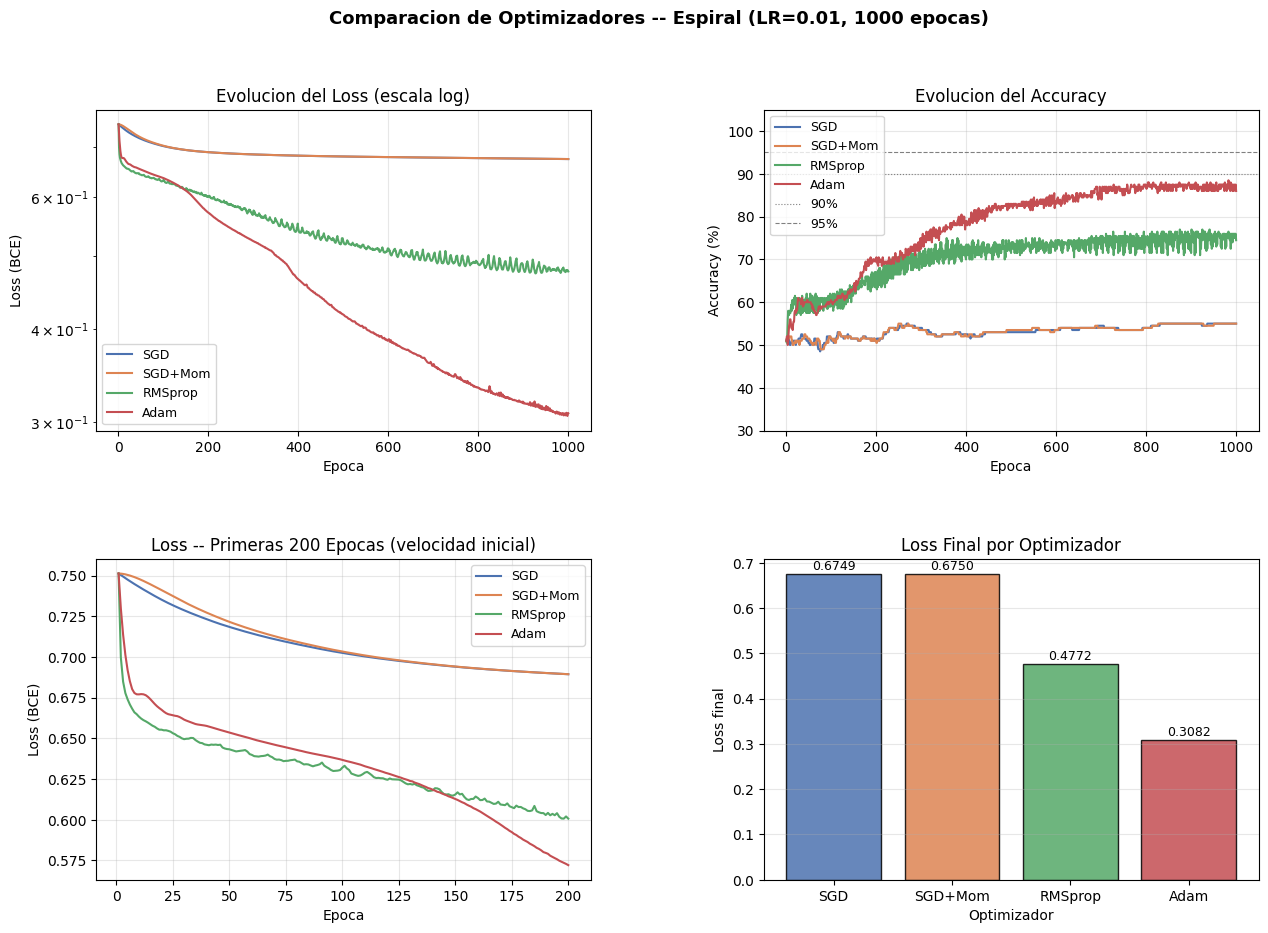

Graficas guardadas como comparacion_optimizadores.png


In [ ]:
colores_opt  = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
nombres_cortos = ['SGD', 'SGD+Mom', 'RMSprop', 'Adam']
epocas_eje   = np.arange(1, EPOCAS + 1)

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)
fig.suptitle('Comparacion de Optimizadores -- Espiral (LR=0.01, 1000 epocas)',
             fontsize=13, fontweight='bold')

# -- Panel 1: Evolucion del Loss --
ax1 = fig.add_subplot(gs[0, 0])
for (nombre, hist), color, nc in zip(resultados.items(), colores_opt, nombres_cortos):
    ax1.plot(epocas_eje, hist['loss'], color=color, linewidth=1.5, label=nc)
ax1.set_title('Evolucion del Loss (escala log)')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss (BCE)')
ax1.set_yscale('log')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# -- Panel 2: Evolucion del Accuracy --
ax2 = fig.add_subplot(gs[0, 1])
for (nombre, hist), color, nc in zip(resultados.items(), colores_opt, nombres_cortos):
    ax2.plot(epocas_eje, hist['acc'] * 100, color=color, linewidth=1.5, label=nc)
ax2.axhline(90, color='gray', linewidth=0.8, linestyle=':', label='90%')
ax2.axhline(95, color='gray', linewidth=0.8, linestyle='--', label='95%')
ax2.set_title('Evolucion del Accuracy')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(30, 105)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# -- Panel 3: Loss primeras 200 epocas (velocidad de convergencia) --
ax3 = fig.add_subplot(gs[1, 0])
for (nombre, hist), color, nc in zip(resultados.items(), colores_opt, nombres_cortos):
    ax3.plot(epocas_eje[:200], hist['loss'][:200], color=color, linewidth=1.5, label=nc)
ax3.set_title('Loss -- Primeras 200 Epocas (velocidad inicial)')
ax3.set_xlabel('Epoca')
ax3.set_ylabel('Loss (BCE)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# -- Panel 4: Loss final por optimizador (barras) --
ax4 = fig.add_subplot(gs[1, 1])
losses_finales = [hist['loss'][-1] for hist in resultados.values()]
bars = ax4.bar(nombres_cortos, losses_finales,
               color=colores_opt, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, losses_finales):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax4.set_title('Loss Final por Optimizador')
ax4.set_xlabel('Optimizador')
ax4.set_ylabel('Loss final')
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('comparacion_optimizadores.png', dpi=110, bbox_inches='tight')
plt.show()
print("Graficas guardadas como comparacion_optimizadores.png")

---
## 10. Analisis y Conclusiones

### 10.1 Diferencias observadas entre configuraciones

Los cuatro optimizadores parten de los mismos pesos iniciales y procesan el mismo dataset, pero producen trayectorias de entrenamiento distintas.

**SGD** realiza actualizaciones uniformes en todas las direcciones del gradiente. Su progreso es constante pero puede ser lento en regiones donde el gradiente es pequeno o tiene alta curvatura, como ocurre en el dataset de espiral. Sin momentum, cada actualizacion es independiente de las anteriores, lo que puede generar oscilaciones en zonas de error con forma de canal elongado.

**SGD con Momentum** suaviza las oscilaciones al acumular una velocidad en la direccion de descenso. Esto le permite avanzar mas rapido en direcciones consistentes y frenar en direcciones que cambian frecuentemente. En la practica, esto se observa como una curva de loss mas suave y una convergencia mas rapida que SGD puro, especialmente en las primeras epocas.

**RMSprop** adapta la tasa de aprendizaje de forma individual por parametro, dividiendo por la raiz cuadrada de la media movil de los gradientes cuadrados. Esto penaliza los parametros que reciben gradientes grandes (reduciendo su paso efectivo) y acelera los que reciben gradientes pequenos. El resultado es un entrenamiento mas estable ante gradientes desiguales.

**Adam** combina los beneficios de Momentum (primer momento) y RMSprop (segundo momento) con correccion de sesgo en las primeras iteraciones. Generalmente logra la convergencia mas rapida y el loss final mas bajo entre las cuatro opciones, siendo el optimizador de referencia en la mayoria de aplicaciones de deep learning modernas.

### 10.2 Estabilidad y velocidad de convergencia

La velocidad de convergencia se evaluo por la epoca en que cada configuracion supero el 90% de accuracy. Los optimizadores adaptativos (RMSprop y Adam) suelen alcanzar ese umbral antes que SGD y SGD+Momentum, especialmente cuando el landscape de optimizacion tiene curvatura heterogenea como en la espiral.

La estabilidad se midio como la desviacion estandar del loss en las ultimas 100 epocas. Un valor cercano a cero indica que el entrenamiento convergio a un minimo estable. SGD puede mostrar mayor variabilidad si la tasa de aprendizaje es grande relativa al gradiente local, mientras que Adam tiende a estabilizarse mas firmemente gracias a su denominador adaptativo.

### 10.3 Efecto de la tasa de aprendizaje (Experimento 2)

El Experimento 2 confirma que incluso el mejor optimizador (Adam) es sensible a la eleccion de la tasa de aprendizaje. Con LR demasiado pequena (0.0001), el aprendizaje es muy lento y puede no converger en 1000 epocas. Con LR demasiado grande (0.1), el loss puede oscilar o divergir porque los pasos de actualizacion superan el ancho del minimo. La region optima para Adam en este problema se encontro en el rango 0.001 -- 0.01, que es consistente con el valor recomendado por defecto en la literatura (0.001).

### 10.4 Principales hallazgos

1. El optimizador no modifica la arquitectura ni el dataset, pero puede determinar si el modelo converge o no dentro de un presupuesto de epocas fijo.
2. Los optimizadores adaptativos (RMSprop, Adam) son en general mas robustos a la eleccion inicial de la tasa de aprendizaje que SGD.
3. SGD con Momentum es un punto medio efectivo: agrega estabilidad sobre SGD puro sin la complejidad computacional de mantener dos momentos.
4. La comparacion valida solo es posible si todos los demas elementos (semilla, arquitectura, dataset) se mantienen constantes. Cambiar mas de un parametro a la vez impide atribuir diferencias de desempeno al componente correcto.
5. El seguimiento de la curva de loss y del accuracy por epoca es indispensable para diagnosticar problemas de entrenamiento (oscilacion, estancamiento, sobreajuste) que no son visibles mirando solo el resultado final.

In [ ]:
print("=" * 60)
print(" Notebook completado exitosamente")
print(" Semana 4 - Optimizacion de Redes Neuronales")
print("=" * 60)
for nombre, hist in resultados.items():
    print(f" {nombre:<35} | Loss: {hist['loss'][-1]:.5f} | Acc: {hist['acc'][-1]*100:.1f}%")
print("=" * 60)

 Notebook completado exitosamente
 Semana 4 - Optimizacion de Redes Neuronales
 SGD (lr=0.01)                       | Loss: 0.67490 | Acc: 55.0%
 SGD+Momentum (lr=0.01, beta=0.9)    | Loss: 0.67497 | Acc: 55.0%
 RMSprop (lr=0.01, rho=0.9)          | Loss: 0.47722 | Acc: 74.5%
 Adam (lr=0.01)                      | Loss: 0.30817 | Acc: 86.0%
